<a href="https://colab.research.google.com/github/devanshh019/codeexpo/blob/main/FUSION_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_pickle("fusion_features_dataset.pkl")

df.head()

,text,emotion,sound,label,urgency
0,"[1.3008546, 1.864815, 0.05988244, 0.46803075, ...","[2.0342631, 0.0, 0.0, 0.0, 0.24019876, 0.0, 0....","[0.0, 0.0, 0.48752624, 0.0, 0.0, 0.0, 4.949202...",domestic_violence,high
1,"[1.8029424, 0.9326464, 0.60693604, 0.5036978, ...","[2.5705042, 0.0, 0.0, 0.0, 0.19596168, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.575213, ...",natural_disaster,critical
2,"[1.0551035, 1.8775334, 1.1153818, 0.499948, 1....","[0.0, 0.9417129, 0.0, 0.0, 0.4723828, 0.0, 0.0...","[0.0, 3.4388413, 14.071653, 18.365202, 0.0, 0....",traffic_accident,high
3,"[0.0, 0.566012, 0.0, 0.09775583, 2.0740426, 2....","[2.8442686, 0.0, 0.0, 0.0, 0.7452919, 0.0, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.1266816, 1.62...",robbery,high
4,"[0.74268353, 2.2943003, 0.8214513, 1.300232, 0...","[0.0, 0.7532223, 1.0385139, 0.0035024174, 0.0,...","[0.0, 13.090834, 0.0, 0.0, 0.0, 0.0, 2.5996318...",drowning,critical


In [ ]:
text = np.stack(df["text"].values)
emotion = np.stack(df["emotion"].values)
sound = np.stack(df["sound"].values)

In [ ]:
print(text.shape)
print(emotion.shape)
print(sound.shape)

(10000, 128)
(10000, 128)
(10000, 128)


In [ ]:
x = np.concatenate([text, emotion, sound], axis=1)

print(x.shape)

(10000, 384)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df["urgency"])

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

fusion_model = tf.keras.Sequential([

    layers.Dense(256, activation="relu", input_shape=(384,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(len(np.unique(y)), activation="softmax")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
fusion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = fusion_model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6957 - loss: 0.8055 - val_accuracy: 0.9815 - val_loss: 0.0498
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9698 - loss: 0.0911 - val_accuracy: 0.9875 - val_loss: 0.0393
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9831 - loss: 0.0483 - val_accuracy: 0.9925 - val_loss: 0.0196
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9899 - loss: 0.0296 - val_accuracy: 0.9965 - val_loss: 0.0139
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9899 - loss: 0.0315 - val_accuracy: 0.9945 - val_loss: 0.0132


In [ ]:
fusion_model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9953 - loss: 0.0100


[0.013155186548829079, 0.9944999814033508]

In [ ]:
from sklearn.metrics import classification_report

y_pred = fusion_model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       745
           1       1.00      0.99      0.99       790
           2       1.00      1.00      1.00       156
           3       0.99      1.00      1.00       309

    accuracy                           0.99      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       0.99      0.99      0.99      2000



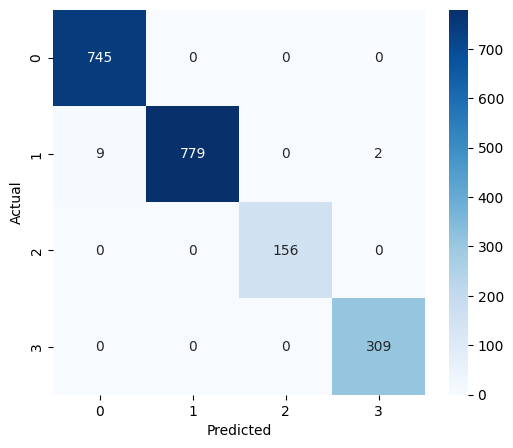

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
fusion_model.save("fusion_model.keras")


In [ ]:
import pickle

with open("label_encoder_fusion.pkl", "wb") as f:
    pickle.dump(le, f)